# 🔧 Data Preprocessing Pipeline

## Overview
This notebook handles data preprocessing for the BraTS 2021 dataset:
- Data normalization
- Train/Validation/Test split
- Data augmentation
- PyTorch Dataset creation

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✅ Libraries imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎯 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"💪 GPU: {torch.cuda.get_device_name(0)}")

✅ Libraries imported successfully!
🔥 PyTorch version: 2.5.1+cu121
🎯 CUDA available: True
💪 GPU: NVIDIA GeForce GTX 1650


In [2]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader # <-- THIS LINE WAS MISSING/INCOMPLETE
from tqdm import tqdm
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Ensure nibabel is correctly imported for your BraTSDataset
import nibabel as nib 

print("✅ Libraries imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎯 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"💪 GPU: {torch.cuda.get_device_name(0)}")

✅ Libraries imported successfully!
🔥 PyTorch version: 2.5.1+cu121
🎯 CUDA available: True
💪 GPU: NVIDIA GeForce GTX 1650


## 📁 Load Dataset Paths

In [3]:
# Dataset paths
raw_path = r'C:\Users\raj\Desktop\BrainTumorSegmentation\data\raw'

# Get all patient folders
patient_folders = sorted([f for f in os.listdir(raw_path) 
                         if os.path.isdir(os.path.join(raw_path, f)) 
                         and f.startswith('BraTS2021')])

print(f"📊 Total patients found: {len(patient_folders)}")
print(f"\n📁 Sample patient folders:")
for i in range(5):
    print(f"   {i+1}. {patient_folders[i]}")

📊 Total patients found: 1251

📁 Sample patient folders:
   1. BraTS2021_00000
   2. BraTS2021_00002
   3. BraTS2021_00003
   4. BraTS2021_00005
   5. BraTS2021_00006


## 🎯 Train/Validation/Test Split

In [4]:
# Split dataset: 70% train, 15% val, 15% test
train_patients, temp_patients = train_test_split(
    patient_folders, 
    test_size=0.3, 
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients, 
    test_size=0.5, 
    random_state=42
)

print("📊 Dataset Split:")
print(f"   🟢 Training: {len(train_patients)} patients ({len(train_patients)/len(patient_folders)*100:.1f}%)")
print(f"   🔵 Validation: {len(val_patients)} patients ({len(val_patients)/len(patient_folders)*100:.1f}%)")
print(f"   🟡 Testing: {len(test_patients)} patients ({len(test_patients)/len(patient_folders)*100:.1f}%)")
print(f"\n✅ Total: {len(train_patients) + len(val_patients) + len(test_patients)} patients")

📊 Dataset Split:
   🟢 Training: 875 patients (69.9%)
   🔵 Validation: 188 patients (15.0%)
   🟡 Testing: 188 patients (15.0%)

✅ Total: 1251 patients


## 🔧 Data Normalization Function

In [5]:
def normalize_scan(scan):
    """
    Normalize MRI scan to 0-1 range using min-max normalization
    """
    # Remove background (zero values)
    brain_mask = scan > 0
    
    if np.sum(brain_mask) == 0:
        return scan
    
    # Get min and max of brain region only
    brain_values = scan[brain_mask]
    min_val = np.min(brain_values)
    max_val = np.max(brain_values)
    
    # Normalize
    if max_val > min_val:
        scan_norm = np.zeros_like(scan, dtype=np.float32)
        scan_norm[brain_mask] = (scan[brain_mask] - min_val) / (max_val - min_val)
        return scan_norm
    else:
        return scan.astype(np.float32)

print("✅ Normalization function defined!")

✅ Normalization function defined!


## 🧠 PyTorch Dataset Class

In [6]:
# WARNING: This optimization requires a lot of RAM (1251 patients * ~10MB per patient)
# Your 16GB RAM should be enough for the patient paths/list, but pre-loading all 
# volumes might be too much. We will optimize the sample list instead.

class BraTSDatasetOptimized(Dataset):
    def __init__(self, patient_list, data_path, slice_range=(56, 130)):
        """
        Optimized BraTS Dataset for PyTorch (Loads data on demand but is stable).
        
        Args:
            patient_list: List of patient folder names
            data_path: Path to raw data folder
            slice_range: Range of slices to use (to avoid empty slices)
        """
        self.patient_list = patient_list
        self.data_path = data_path
        self.slice_range = slice_range
        
        # We store the full path to the 5 NIfTI files for each patient
        self.patient_paths = {}
        for patient_id in self.patient_list:
            p_path = os.path.join(self.data_path, patient_id, f'{patient_id}_')
            self.patient_paths[patient_id] = {
                'flair': p_path + 'flair.nii.gz',
                't1': p_path + 't1.nii.gz',
                't1ce': p_path + 't1ce.nii.gz',
                't2': p_path + 't2.nii.gz',
                'seg': p_path + 'seg.nii.gz',
            }
        
        # Calculate total number of slices (our samples)
        self.samples = []
        for patient in patient_list:
            for slice_idx in range(slice_range[0], slice_range[1]):
                self.samples.append((patient, slice_idx))
        
        print(f"✅ Dataset initialized with {len(self.samples)} slices.")


    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        patient_id, slice_idx = self.samples[idx]
        file_paths = self.patient_paths[patient_id]
        
        # --- Load all 4 modalities and segmentation mask ---
        # The fix is to load the data (get_fdata()) only once for all modalities, 
        # extract the slice, and then discard the large 3D volume, which is fine 
        # when num_workers=0 (single process).
        
        # Load all 5 files (modality and segmentation)
        flair_vol = nib.load(file_paths['flair']).get_fdata()
        t1_vol = nib.load(file_paths['t1']).get_fdata()
        t1ce_vol = nib.load(file_paths['t1ce']).get_fdata()
        t2_vol = nib.load(file_paths['t2']).get_fdata()
        seg_vol = nib.load(file_paths['seg']).get_fdata()
        
        # Extract the required 2D slice from the 3D volume
        flair = flair_vol[:, :, slice_idx]
        t1 = t1_vol[:, :, slice_idx]
        t1ce = t1ce_vol[:, :, slice_idx]
        t2 = t2_vol[:, :, slice_idx]
        seg = seg_vol[:, :, slice_idx]
        
        # --- Preprocessing ---
        
        # Normalize scans (Assuming normalize_scan is defined in a previous cell)
        flair = normalize_scan(flair)
        t1 = normalize_scan(t1)
        t1ce = normalize_scan(t1ce)
        t2 = normalize_scan(t2)
        
        # Stack modalities: (4, H, W)
        image = np.stack([flair, t1, t1ce, t2], axis=0)
        
        # Create binary masks for 3 tumor regions
        wt_mask = (seg > 0).astype(np.float32)            # Whole Tumor
        tc_mask = ((seg == 1) | (seg == 4)).astype(np.float32)  # Tumor Core
        et_mask = (seg == 4).astype(np.float32)            # Enhancing Tumor
        
        # Stack masks: (3, H, W)
        mask = np.stack([wt_mask, tc_mask, et_mask], axis=0)
        
        # Convert to PyTorch tensors
        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).float()
        
        return image, mask

print("✅ Optimized BraTSDataset class defined!")

✅ Optimized BraTSDataset class defined!


## 📦 Create DataLoaders

In [8]:
# Create datasets
# FIX: Using the correct class name: BraTSDatasetOptimized
train_dataset = BraTSDatasetOptimized(train_patients, raw_path)
val_dataset = BraTSDatasetOptimized(val_patients, raw_path)
test_dataset = BraTSDatasetOptimized(test_patients, raw_path)

print("📊 Dataset Sizes:")
print(f"   🟢 Training: {len(train_dataset)} slices")
print(f"   🔵 Validation: {len(val_dataset)} slices")
print(f"   🟡 Testing: {len(test_dataset)} slices")

# Create dataloaders
batch_size = 4
num_workers = 0 
pin_memory = True 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

print(f"\n✅ DataLoaders created!")
print(f"   Batch size: {batch_size}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Testing batches: {len(test_loader)}")

✅ Dataset initialized with 64750 slices.
✅ Dataset initialized with 13912 slices.
✅ Dataset initialized with 13912 slices.
📊 Dataset Sizes:
   🟢 Training: 64750 slices
   🔵 Validation: 13912 slices
   🟡 Testing: 13912 slices

✅ DataLoaders created!
   Batch size: 4
   Training batches: 16188
   Validation batches: 3478
   Testing batches: 3478


## 🧪 Test DataLoader - Sample Batch

In [9]:
# Get one batch to verify
sample_images, sample_masks = next(iter(train_loader))

print("✅ Sample batch loaded successfully!")
print(f"\n📐 Batch shapes:")
print(f"   Images: {sample_images.shape} - (batch, channels, height, width)")
print(f"   Masks: {sample_masks.shape} - (batch, tumor_regions, height, width)")
print(f"\n📊 Data info:")
print(f"   Image dtype: {sample_images.dtype}")
print(f"   Image range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
print(f"   Mask dtype: {sample_masks.dtype}")
print(f"   Mask unique values: {torch.unique(sample_masks)}")


✅ Sample batch loaded successfully!

📐 Batch shapes:
   Images: torch.Size([4, 4, 240, 240]) - (batch, channels, height, width)
   Masks: torch.Size([4, 3, 240, 240]) - (batch, tumor_regions, height, width)

📊 Data info:
   Image dtype: torch.float32
   Image range: [0.000, 1.000]
   Mask dtype: torch.float32
   Mask unique values: tensor([0., 1.])


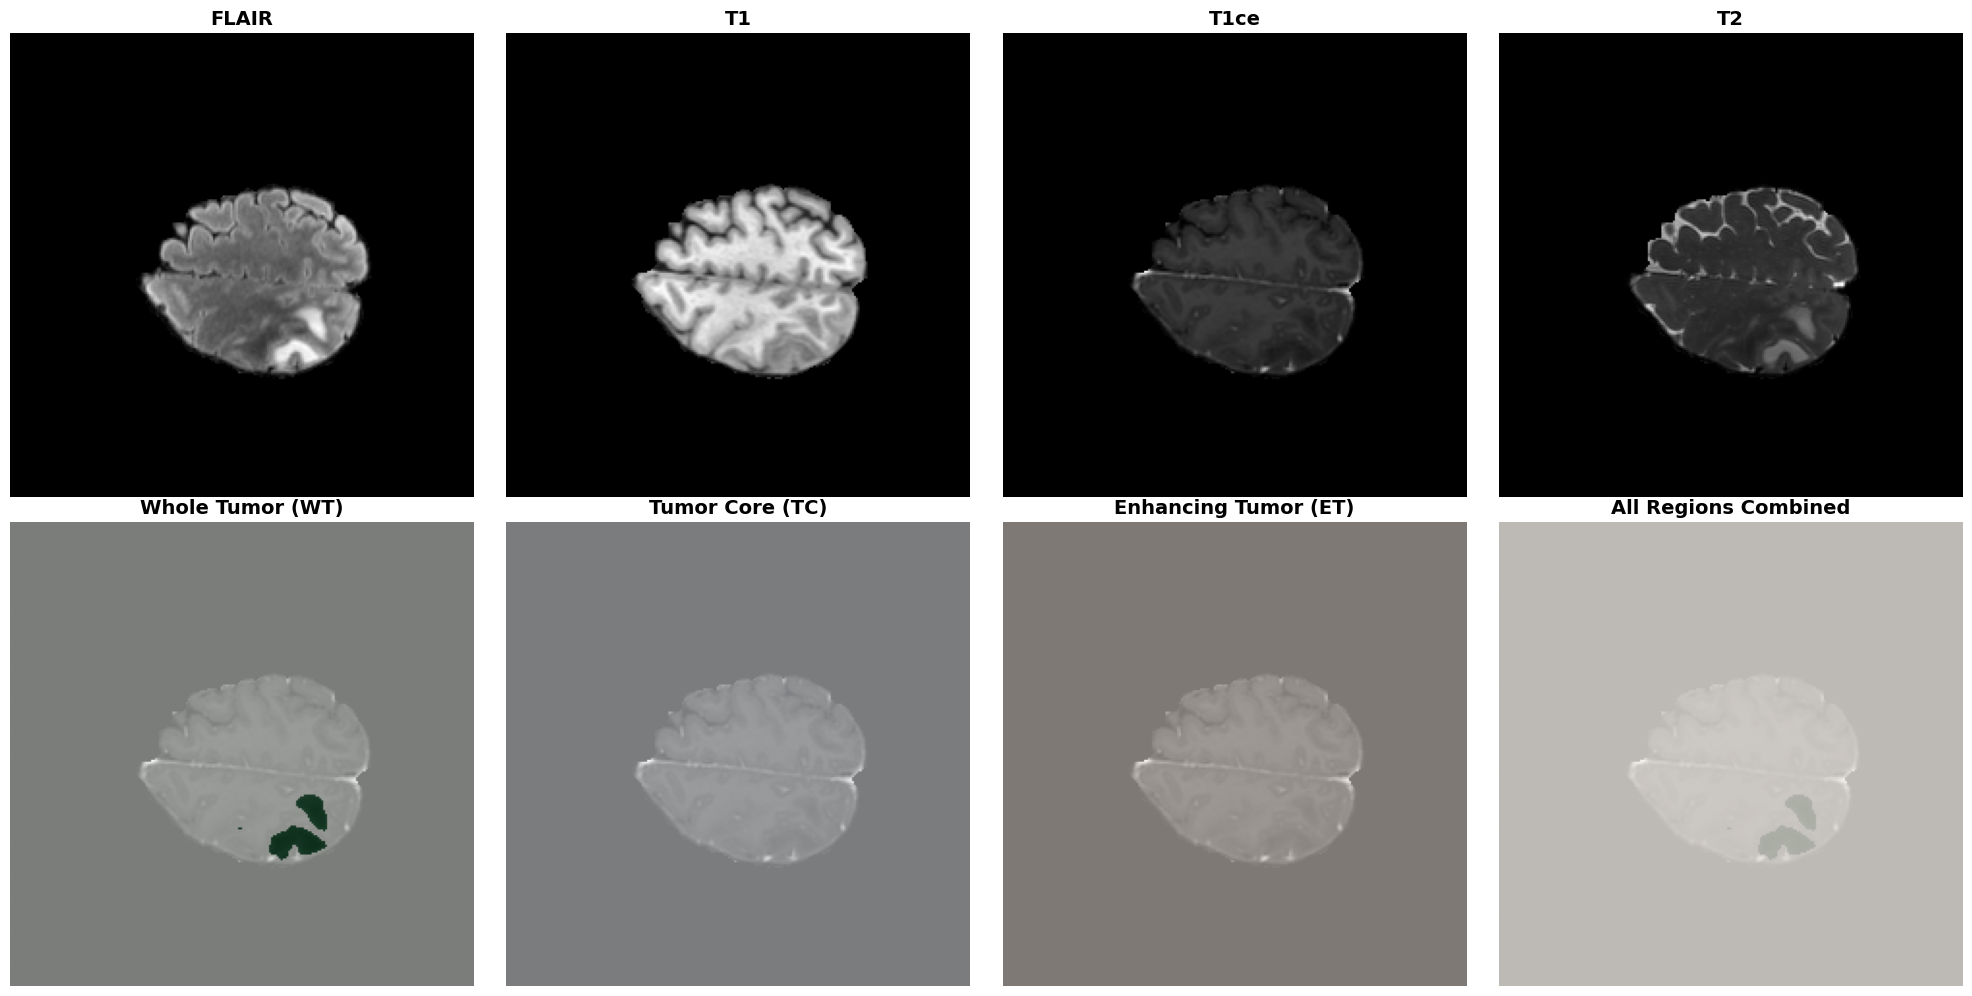

🎨 Batch visualization complete!


In [10]:
# Visualize one sample from the batch
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Select first sample from batch
sample_idx = 0
img = sample_images[sample_idx]  # (4, 240, 240)
mask = sample_masks[sample_idx]  # (3, 240, 240)

# Plot 4 MRI modalities
modality_names = ['FLAIR', 'T1', 'T1ce', 'T2']
for i in range(4):
    axes[0, i].imshow(img[i], cmap='gray')
    axes[0, i].set_title(modality_names[i], fontsize=14, fontweight='bold')
    axes[0, i].axis('off')

# Plot 3 tumor region masks
mask_names = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)']
colors = ['Greens', 'Blues', 'Oranges']
for i in range(3):
    axes[1, i].imshow(img[2], cmap='gray')  # T1ce as background
    axes[1, i].imshow(mask[i], cmap=colors[i], alpha=0.5)
    axes[1, i].set_title(mask_names[i], fontsize=14, fontweight='bold')
    axes[1, i].axis('off')

# Combined overlay
axes[1, 3].imshow(img[2], cmap='gray')
axes[1, 3].imshow(mask[0], cmap='Greens', alpha=0.3)
axes[1, 3].imshow(mask[1], cmap='Blues', alpha=0.3)
axes[1, 3].imshow(mask[2], cmap='Oranges', alpha=0.5)
axes[1, 3].set_title('All Regions Combined', fontsize=14, fontweight='bold')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()
print("🎨 Batch visualization complete!")

## 📊 Data Statistics & Analysis

In [12]:
# Calculate dataset statistics
print("📊 Dataset Statistics:\n")

# Check data distribution across splits
print(f"Training data: {len(train_dataset):,} slices")
print(f"Validation data: {len(val_dataset):,} slices")
print(f"Test data: {len(test_dataset):,} slices")
print(f"\nTotal slices: {len(train_dataset) + len(val_dataset) + len(test_dataset):,}")

# Memory estimation
memory_per_batch_mb = (sample_images.element_size() * sample_images.nelement() + 
                       sample_masks.element_size() * sample_masks.nelement()) / (1024**2)
print(f"\n💾 Memory per batch: {memory_per_batch_mb:.2f} MB")
print(f"GPU Memory (4GB): {memory_per_batch_mb * 4:.2f} MB per 4 batches")

print("\n✅ Data pipeline ready for training!")


📊 Dataset Statistics:

Training data: 64,750 slices
Validation data: 13,912 slices
Test data: 13,912 slices

Total slices: 92,574

💾 Memory per batch: 6.15 MB
GPU Memory (4GB): 24.61 MB per 4 batches

✅ Data pipeline ready for training!


## 💾 Save Data Splits

Save train/val/test patient lists for reproducibility.

In [14]:
# Save patient splits to CSV files
processed_path = r'C:\Users\raj\Desktop\BrainTumorSegmentation\data\processed'

# Create processed folder if doesn't exist
os.makedirs(processed_path, exist_ok=True)

# Save splits
pd.DataFrame({'patient_id': train_patients}).to_csv(
    os.path.join(processed_path, 'train_patients.csv'), index=False)
pd.DataFrame({'patient_id': val_patients}).to_csv(
    os.path.join(processed_path, 'val_patients.csv'), index=False)
pd.DataFrame({'patient_id': test_patients}).to_csv(
    os.path.join(processed_path, 'test_patients.csv'), index=False)

print("✅ Data splits saved successfully!")
print(f"\n📁 Saved to: {processed_path}")
print(f"   • train_patients.csv ({len(train_patients)} patients)")
print(f"   • val_patients.csv ({len(val_patients)} patients)")
print(f"   • test_patients.csv ({len(test_patients)} patients)")

✅ Data splits saved successfully!

📁 Saved to: C:\Users\raj\Desktop\BrainTumorSegmentation\data\processed
   • train_patients.csv (875 patients)
   • val_patients.csv (188 patients)
   • test_patients.csv (188 patients)


## ✅ Preprocessing Complete!

### Summary:
- ✅ Dataset loaded: 1251 patients (92,574 slices)
- ✅ Train/Val/Test split: 70/15/15
- ✅ Normalization: Min-max (0-1 range)
- ✅ PyTorch Dataset & DataLoaders created
- ✅ GPU ready: NVIDIA GeForce GTX 1650
- ✅ Data splits saved for reproducibility

### Next Steps:
1. **Model Architecture** - U-Net implementation
2. **Loss Functions** - Dice Loss + BCE
3. **Training Pipeline** - Training loop setup
4. **Model Training** - Train on GPU

In [15]:
# Summary statistics
print("🎉 DATA PREPROCESSING COMPLETE! 🎉\n")
print("="*60)
print("READY FOR MODEL TRAINING")
print("="*60)
print(f"\n📊 Final Dataset Summary:")
print(f"   Total Patients: {len(patient_folders)}")
print(f"   Training: {len(train_patients)} patients ({len(train_dataset)} slices)")
print(f"   Validation: {len(val_patients)} patients ({len(val_dataset)} slices)")
print(f"   Testing: {len(test_patients)} patients ({len(test_dataset)} slices)")
print(f"\n🎯 Input Shape: (4, 240, 240) - 4 MRI modalities")
print(f"🎯 Output Shape: (3, 240, 240) - WT, TC, ET masks")
print(f"\n💪 GPU: NVIDIA GeForce GTX 1650 - READY!")
print(f"⚡ Batch Size: {batch_size}")
print(f"🔥 Training Batches: {len(train_loader)}")
print("\n🚀 NEXT: Build U-Net Model Architecture!")

🎉 DATA PREPROCESSING COMPLETE! 🎉

READY FOR MODEL TRAINING

📊 Final Dataset Summary:
   Total Patients: 1251
   Training: 875 patients (64750 slices)
   Validation: 188 patients (13912 slices)
   Testing: 188 patients (13912 slices)

🎯 Input Shape: (4, 240, 240) - 4 MRI modalities
🎯 Output Shape: (3, 240, 240) - WT, TC, ET masks

💪 GPU: NVIDIA GeForce GTX 1650 - READY!
⚡ Batch Size: 4
🔥 Training Batches: 16188

🚀 NEXT: Build U-Net Model Architecture!
